# *Drosophila* pipeline (demo)

**This notebook is a pipeline demonstration**, not the canonical source for the published figures.  For paper-ready PNG / PDF regeneration of every panel of Fig. 4, Fig. 5, and Supp. Figs. 6--10, use `figures/figure_4.py`, `figures/figure_5.py`, and `figures/supp_figure_{6,7,8,9,10}.py`, or run `python figures/run_all.py` from the repository root.

What this notebook does: takes the shipped joint-angle wavelet PCs, runs the pipeline through G-PCCA at $M=4$, and projects the resulting basin memberships onto the Berman 2014 behavioral map.

In [2]:
# --- Colab / local setup ---
# If you're running on Colab, uncomment the next two lines to install the
# pip dependencies that aren't in the default Colab image (and to clone
# this repo for the helper modules + data).
#
# !pip install pygpcca powerlaw umap-learn
# !git clone https://github.com/<your-org>/slowmode.git
# %cd slowmode

import os, sys, pickle, time
import numpy as np
import matplotlib.pyplot as plt

# Ensure slowmode/ is on the path.
sys.path.insert(0, os.path.abspath('.'))

import pipeline as pp
import gpcca_utils as gu
import figures as fg

fg.setup_style()
os.makedirs('outputs', exist_ok=True)


In [3]:
# --- imports specific to this notebook ---
from sklearn.decomposition import PCA
import warnings; warnings.filterwarnings('ignore', category=UserWarning)


## 1. Load the fly wavelet-PC, behavior-map, and cluster sequences

`flies_wlets_pca.pkl` is a list of 30 flies, each a $(360001, 15)$ array of
wavelet PCA projections.

`flies_zvals.pkl` is a list of 30 $(360001, 2)$ arrays giving the Berman
2014 behavior-map coordinates (used for Fig. 5A).

`flies_state_partitions.pkl` is a $\{fly \to \text{int array of length}~ 359990\}$
dict of cached cluster sequences from $k$-means at $N = 1000$.


In [4]:
DATA_DIR = 'data'

# === LOCAL DATA (use this while the Zenodo upload is not yet live) ===
with open(f'{DATA_DIR}/flies_wlets_pca.pkl', 'rb') as f:
    wlets_pca = pickle.load(f)
with open(f'{DATA_DIR}/flies_zvals.pkl', 'rb') as f:
    zvals_per_fly = pickle.load(f)
with open(f'{DATA_DIR}/flies_state_partitions.pkl', 'rb') as f:
    states_per_fly = pickle.load(f)

# === ZENODO DATA (replace block above with this after upload) ===
# ZENODO_BASE = 'https://zenodo.org/records/<id>/files'
# !mkdir -p data
# !wget -nc {ZENODO_BASE}/flies_wlets_pca.pkl        -P data/
# !wget -nc {ZENODO_BASE}/flies_zvals.pkl            -P data/
# !wget -nc {ZENODO_BASE}/flies_state_partitions.pkl -P data/

n_flies = len(wlets_pca)
print(f'{n_flies} flies; wlets_pca[0].shape = {wlets_pca[0].shape}')
print(f'zvals[0].shape = {zvals_per_fly[0].shape}')
print(f'states[0].shape = {states_per_fly[0].shape}')

# Pooled wavelet-PC array used by the Cao and other diagnostic cells.
all_pcs = np.concatenate(wlets_pca)
print(f'pooled wlets_pca: {all_pcs.shape}')


30 flies; wlets_pca[0].shape = (360001, 15)
zvals[0].shape = (360001, 2)
states[0].shape = (359990,)
pooled wlets_pca: (10701423, 15)


## 2. Pool cluster sequences and build $T(\tau = 2~\mathrm{s})$


In [5]:
fs = 100.0
tau_seconds = 2.0
lag = int(tau_seconds * fs)            # 200 frames

all_states = np.concatenate([states_per_fly[i].astype(int)
                              for i in sorted(states_per_fly)])
N = int(all_states.max()) + 1
print(f'pooled states: T = {len(all_states):,}    N = {N}    lag = {lag}')

T_multi = pp.make_transition_matrix(all_states, lag=lag, n_states=N)
pi_multi = pp.stationary_distribution(T_multi)
evals_multi, evecs_multi = pp.leading_eigvecs(T_multi, k=10)
phi_mt = evecs_multi[:, :3].real     # (N, 3) for the eigenspace plots
print(f'leading |lambda_k| = {np.abs(evals_multi)[:6].round(4)}')

M_pick, gap, ratios = gu.select_M_spectral_gap(evals_multi, M_min=2, M_max=8)
print(f'spectral gap selects M = {M_pick} (gap ratio = {gap:.3f})')


pooled states: T = 10,701,093    N = 1000    lag = 200
leading |lambda_k| = [0.8771 0.8063 0.7431 0.5986 0.5705 0.5597]
spectral gap selects M = 3 (gap ratio = 1.241)


## 3. G-PCCA at $M = 4$


In [6]:
out = gu.run_gpcca(T_multi, M=4, eta=pi_multi)
chi = out['chi']
print(f'crispness    = {out["crispness"]:.3f}')
print(f'basin counts = {out["basin_counts"]}')
print(f'pi per basin = {out["pi_basin"].round(3)}')

# Hub-and-arm geometry in (phi_2, phi_3, phi_4).
geo = gu.compute_hub_arms(phi_mt, pi_multi, chi)
print('arm lengths:', geo['arm_lengths'].round(3))


crispness    = 0.602
basin counts = [416 312 184  88]
pi per basin = [0.337 0.309 0.214 0.14 ]
arm lengths: [0.051 0.053 0.064 0.103]


## 4. Fixed-timescale comparison (Fig. 4A negative control)

Re-run the pipeline without the wavelet step: delay-embed the raw 15-D
wavelet-PCs at $d = 8$ (the value selected by the body-text Lorenz Cao
analogue, since the joint-angle Cao saturation is at $d = 8$ here too).

For speed we use a smaller $N$ for this control panel; the published
analysis uses $N = 1000$.


In [7]:
# Fixed-timescale baseline.  The paper builds this from the raw joint-angle
# trajectories at N = 3000 clusters, d = 8, tau = 2 s.  We ship the cached
# cluster sequences in data/flies_state_partitions_fixed.pkl so reviewers
# don't need the 1.9 GB joint-angle file to reproduce Fig 4A.
with open(f'{DATA_DIR}/flies_state_partitions_fixed.pkl', 'rb') as f:
    states_per_fly_fixed = pickle.load(f)

all_states_fix = np.concatenate([states_per_fly_fixed[i].astype(int)
                                  for i in sorted(states_per_fly_fixed)])
N_fix = int(all_states_fix.max()) + 1
print(f'fixed: pooled states T = {len(all_states_fix):,}, N = {N_fix}')

T_fix = pp.make_transition_matrix(all_states_fix, lag=lag, n_states=N_fix)
pi_fix = pp.stationary_distribution(T_fix)
evals_fix, evecs_fix = pp.leading_eigvecs(T_fix, k=10)
phi_fix = evecs_fix[:, :3].real
print(f'fixed |lambda_k| = {np.abs(evals_fix)[:6].round(4)}')
print(f'PR (fixed) = {pp.participation_ratio(phi_fix).round(2)}')
print(f'PR (multi) = {pp.participation_ratio(phi_mt).round(2)}')


fixed: pooled states T = 10,701,003, N = 3000
fixed |lambda_k| = [0.9768 0.9763 0.9734 0.9687 0.9666 0.9661]
PR (fixed) = [1.29 7.71 3.43]
PR (multi) = [384.8  225.11 442.75]


## Fig. 4A — fixed-timescale 3D eigenspace, three localization clusters

The fixed-timescale operator places almost all of its slow-mode weight on a
handful of clusters: PR$_k = 1, 3, 3$.  We highlight the three top-norm
clusters in red/teal/gold.


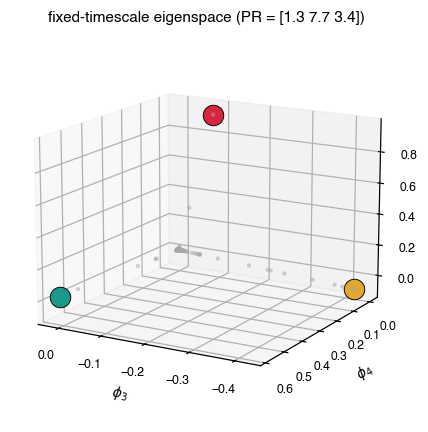

In [8]:
# Fig 4A: highlight three localization clusters in the fixed-timescale
# eigenspace.  Paper recipe: sort clusters by L2 norm in (phi_2, phi_3, phi_4),
# walk down and keep the first three whose unit-direction vectors are mutually
# distinct (cosine < 0.9).  These are the localization spikes that give
# PR ~ 1, 3, 3.  Axis convention matches the published figure: x = phi_3,
# y = phi_4, z = phi_2; view = (elev=15, azim=120).
from mpl_toolkits.mplot3d import Axes3D  # noqa

norms_f = np.linalg.norm(phi_fix, axis=1)
order = np.argsort(norms_f)[::-1]
seen_dirs, hi_idx = [], []
for cid in order:
    d_i = phi_fix[cid] / max(np.linalg.norm(phi_fix[cid]), 1e-12)
    if any(abs(d_i @ u) > 0.9 for u in seen_dirs):
        continue
    seen_dirs.append(d_i); hi_idx.append(cid)
    if len(hi_idx) >= 3: break

# Axis permutation: column 1 -> x, column 2 -> y, column 0 -> z.
def xyz_of(p):
    return p[..., 1], p[..., 2], p[..., 0]

fig = plt.figure(figsize=(4.6, 4.0))
ax = fig.add_subplot(111, projection='3d')
fx, fy, fz = xyz_of(phi_fix)
ax.scatter(fx, fy, fz, s=8, c='0.65', alpha=0.5,
            edgecolors='none', depthshade=False)
hi_palette = ['#d7263d', '#1b998b', '#e3a72f']
for k, cid in enumerate(hi_idx):
    px, py, pz = xyz_of(phi_fix[cid])
    ax.scatter([px], [py], [pz], s=180, c=hi_palette[k],
                edgecolors='k', linewidths=0.6, zorder=10)
ax.view_init(elev=15, azim=120)
ax.set_xlabel(r'$\phi_3$'); ax.set_ylabel(r'$\phi_4$'); ax.set_zlabel(r'$\phi_2$')
ax.set_title(f'fixed-timescale eigenspace (PR = {pp.participation_ratio(phi_fix).round(1)})')
plt.tight_layout()
fg.save_panel(fig, 'fig4A_fixed_eigenspace')
plt.show()


## Fig. 4B — multi-timescale 3D eigenspace with four arms


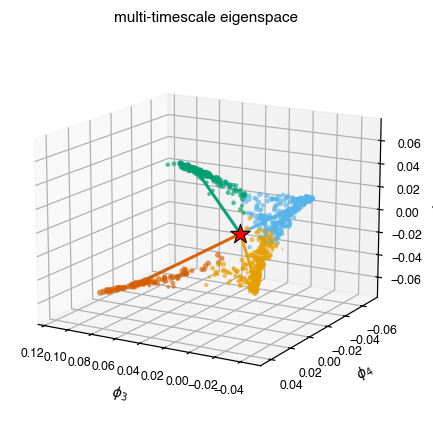

In [9]:
fig = plt.figure(figsize=(4.6, 4.0))
ax = fig.add_subplot(111, projection='3d')
fg.plot_eigenspace_3d(
    ax, phi_mt, pi=pi_multi, chi=chi,
    hub=geo['hub'], arm_dirs=geo['arm_dirs'],
    arm_centroids=geo['arm_centroids'],
    palette=fg.ARM_PALETTE,
    view=(15, 120),
    axis_order=(1, 2, 0),
    axis_labels=(r'$\phi_3$', r'$\phi_4$', r'$\phi_2$'))
ax.set_title('multi-timescale eigenspace')
plt.tight_layout()
fg.save_panel(fig, 'fig4B_multi_eigenspace')
plt.show()


## Fig. 4C — eigenvalue spectrum


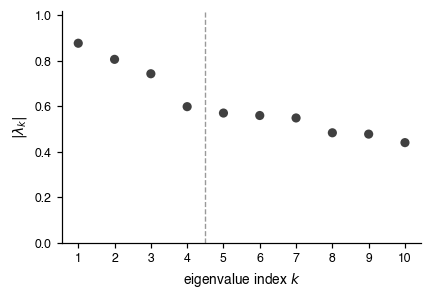

In [10]:
fig, ax = plt.subplots(figsize=(4.0, 2.8))
fg.plot_eigenvalue_dots(ax, evals_multi[:10], M=4)
plt.tight_layout()
fg.save_panel(fig, 'fig4C_eigenvalue_spectrum')
plt.show()


## Fig. 4D — representative $\chi_j(t)$ for one fly

Soft basin memberships $\chi_j(t)$ for one representative fly over the
first 20 minutes, with a 5 s rolling smoothing window.  Multiple $\chi_j$
are simultaneously elevated and the dominant arm shifts gradually,
reproducing the continuous, graded organization documented in Berman et
al. (2014, 2016).


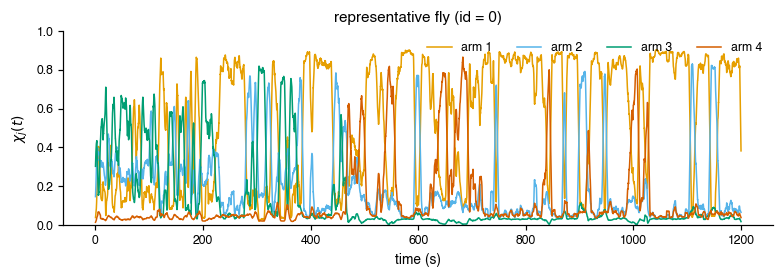

In [11]:
fly_id = 0
states_fly = states_per_fly[fly_id].astype(int)
T_window = 20 * 60 * int(fs)        # 20 minutes
chi_fly = chi[states_fly[:T_window]]
t_fly = np.arange(T_window) / fs

fig, ax = plt.subplots(figsize=(7.2, 2.6))
fg.plot_chi_timeseries(ax, t_fly, chi_fly, palette=fg.ARM_PALETTE,
                        smoothing_window=int(5 * fs),
                        labels=[f'arm {j+1}' for j in range(4)])
ax.set_title(f'representative fly (id = {fly_id})')
plt.tight_layout()
fg.save_panel(fig, 'fig4D_chi_timeseries')
plt.show()


## Fig. 5A — $\chi$-weighted behavior-map enrichment quartet

Per-arm enrichment density on the Berman 2014 behavioral map.  For each arm
$j$ we compute the $\chi_j$-weighted occupancy density on a 2D grid in
$(z_1, z_2)$, then subtract the across-arm mean so that red regions are
enriched and blue depleted.

Each panel is rendered separately (one per arm), in the Okabe-Ito palette
order (idle & slow / anterior / posterior & wing / locomotion gaits).


In [12]:
all_zvals = np.concatenate(zvals_per_fly)        # (T_total, 2)
print(f'all_zvals.shape = {all_zvals.shape}; all_states len = {len(all_states)}')
# zvals are aligned to wavelet-PC frames; states are indexed by the
# delay-embedded reduction (loses (d-1)*tau frames at the start of each fly).
# The cached state partitions in the data file are post-embedding so we
# must align by tail-trimming the zvals per fly to match.
# Reconstruct the alignment used to produce the cache:
T_per_fly_state = states_per_fly[0].shape[0]    # 359990
T_per_fly_pcs = wlets_pca[0].shape[0]           # 360001
trim = T_per_fly_pcs - T_per_fly_state          # frames lost to embedding
print(f'embedding trim per fly = {trim} frames')

aligned_zvals = np.concatenate([z[trim:] for z in zvals_per_fly])
print(f'aligned_zvals shape = {aligned_zvals.shape}; matches states? '
      f'{len(aligned_zvals) == len(all_states)}')
chi_per_frame = chi[all_states]


all_zvals.shape = (10701423, 2); all_states len = 10701093
embedding trim per fly = 11 frames
aligned_zvals shape = (10701093, 2); matches states? True


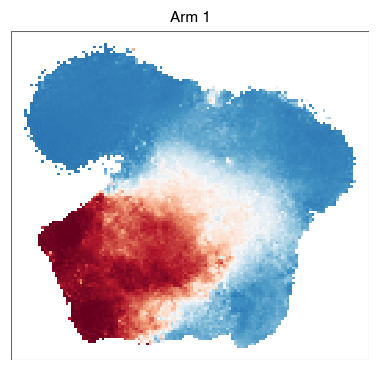

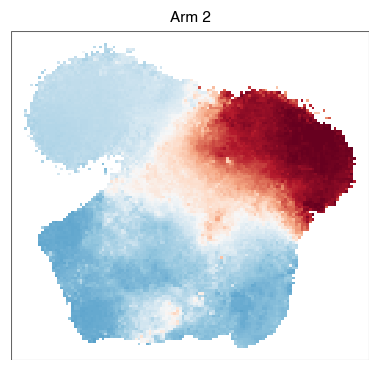

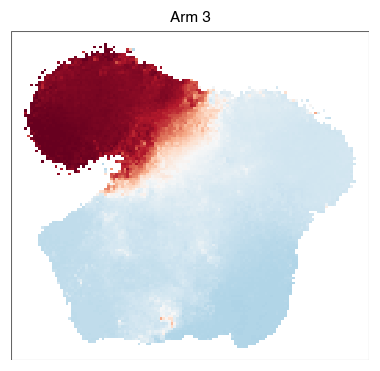

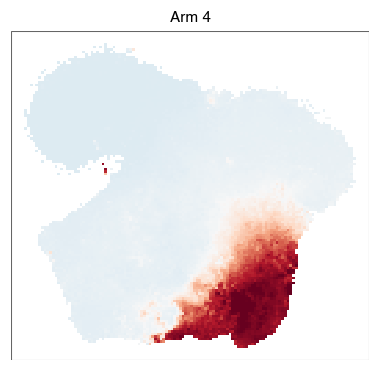

In [13]:
arm_titles = ['Arm 1', 'Arm 2',
              'Arm 3', 'Arm 4']
mean_chi = chi[:, :].mean(axis=0)
for j in range(4):
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    fg.plot_density_map(ax, aligned_zvals[:, 0], aligned_zvals[:, 1],
                         chi_per_frame[:, j] - mean_chi[j],
                         n_bins=120, min_count=20)
    ax.set_title(arm_titles[j])
    fg.save_panel(fig, f'fig5A_arm{j+1}_behavior_map')
    plt.show()


## Fig. 5B — apparent decay rate $r_k(\tau)$ vs lag

If the dynamics were Markovian at the chosen state resolution, each
$r_k(\tau) = -\log|\lambda_k(\tau)| / \tau$ would be constant in
$\tau$; instead, $r_2$ decreases ~120× over $\tau \in [0.01, 200]$ s.


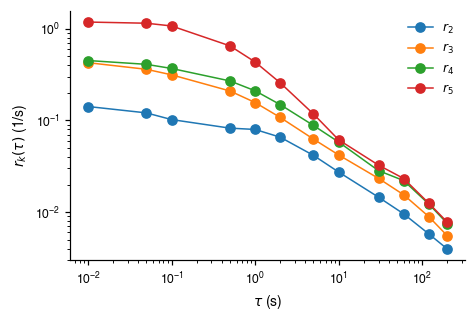

In [14]:
lags_seconds = np.array([0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0,
                          30.0, 60.0, 120.0, 200.0])
lags_frames = (lags_seconds * fs).astype(int)
r_k_full = np.zeros((len(lags_frames), 4))
for li, lg in enumerate(lags_frames):
    Tk = pp.make_transition_matrix(all_states, lag=int(lg), n_states=N)
    ev, _ = pp.leading_eigvecs(Tk, k=4)
    r_k_full[li] = -np.log(np.maximum(np.abs(ev[:4]), 1e-12)) / (lg / fs)

fig, ax = plt.subplots(figsize=(4.4, 3.0))
for k in range(4):
    ax.plot(lags_seconds, r_k_full[:, k], 'o-', lw=1.0,
             label=fr'$r_{{{k+2}}}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel(r'$r_k(\tau)$ (1/s)'); ax.legend()
plt.tight_layout()
fg.save_panel(fig, 'fig5B_r_k_vs_tau')
plt.show()


## Fig. 5C — predictive MI vs Markov prediction

We compare the empirical predictive mutual information
$I(\mathrm{arm}(t); \mathrm{arm}(t+\tau))$ between basin labels at two
times to the Markov prediction obtained by propagating
$T_\mathrm{basin}(\tau = 1~\mathrm{s})$ forward.


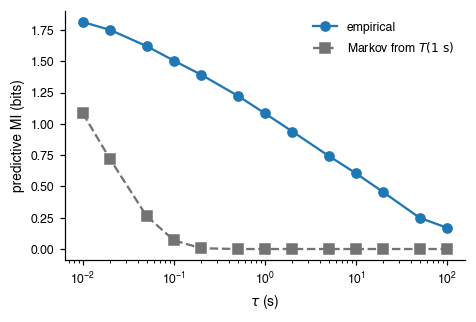

In [15]:
def predictive_mi(seq, lag):
    seq = np.asarray(seq, dtype=int)
    M = int(seq.max()) + 1
    counts = np.zeros((M, M))
    np.add.at(counts, (seq[:-lag], seq[lag:]), 1.0)
    p = counts / counts.sum()
    pi = p.sum(axis=1); pj = p.sum(axis=0)
    mi = 0.0
    for i in range(M):
        for j in range(M):
            if p[i, j] > 0 and pi[i] > 0 and pj[j] > 0:
                mi += p[i, j] * np.log2(p[i, j] / (pi[i] * pj[j]))
    return mi

# Lump cluster sequence -> basin sequence.
basin_assign = chi.argmax(axis=1)
basin_seq = basin_assign[all_states]

# Empirical MI vs lag.
lag_grid = np.unique(np.r_[1, 2, 5, 10, 20, 50, 100, 200, 500,
                            1000, 2000, 5000, 10000])
mi_emp = np.array([predictive_mi(basin_seq, int(l * fs / 100)) for l in lag_grid])
# Markov prediction from T(tau=1s).
T1, pi1, _ = gu.lump_to_basin_msm(all_states, chi, lag=int(fs))
mi_markov = np.zeros_like(mi_emp, dtype=float)
for li, l in enumerate(lag_grid):
    n_steps = max(int(l), 1)
    Tn = np.linalg.matrix_power(T1, n_steps)
    p = pi1[:, None] * Tn
    pj = p.sum(axis=0)
    mi_v = 0.0
    for i in range(p.shape[0]):
        for j in range(p.shape[1]):
            if p[i, j] > 0 and pi1[i] > 0 and pj[j] > 0:
                mi_v += p[i, j] * np.log2(p[i, j] / (pi1[i] * pj[j]))
    mi_markov[li] = mi_v

fig, ax = plt.subplots(figsize=(4.4, 3.0))
ax.plot(lag_grid / fs, mi_emp, 'o-', color='C0', label='empirical')
ax.plot(lag_grid / fs, mi_markov, 's--', color='0.45',
         label=r'Markov from $T(1~\mathrm{s})$')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel('predictive MI (bits)')
ax.legend()
plt.tight_layout()
fg.save_panel(fig, 'fig5C_predictive_mi')
plt.show()


## Fig. 5D — Costa per-fly $\sigma_\mathrm{slow}$ vs $\alpha$ (pooled)

For each fly $\times$ arm pair we estimate (i) the dwell-time exponent
$\alpha$ by maximum-likelihood power-law fit (Clauset et al. 2009), and
(ii) the within-fly fluctuation strength $\sigma_\mathrm{slow}$ as the
standard deviation of the 60-s-windowed basin membership $\bar{\chi}_j$.
The Costa–Ahamed prediction is a negative correlation across pairs.

The published analysis runs the full per-arm dissection and the spectral
$\sigma_\mathrm{slow}$ definition; those panels are in Figs. S6 and S7
respectively.


118 fly-arm pairs


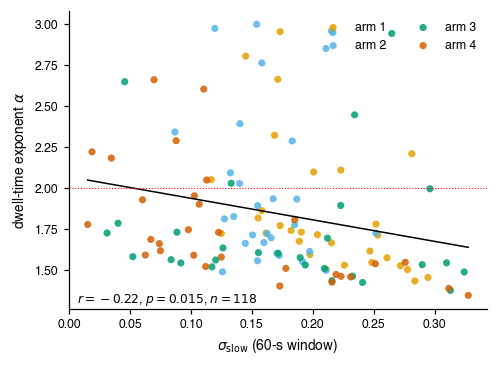

  arm 1: n = 30, r = -0.472  p = 0.008,  mean alpha = 1.85
  arm 2: n = 30, r = +0.016  p = 0.932,  mean alpha = 2.03
  arm 3: n = 28, r = -0.070  p = 0.723,  mean alpha = 1.73
  arm 4: n = 30, r = -0.598  p = 0.000,  mean alpha = 1.76


In [16]:
from powerlaw import Fit
from scipy.stats import pearsonr

W_seconds = 60.0
W = int(W_seconds * fs)

records = []
for fly_id in sorted(states_per_fly):
    sf = states_per_fly[fly_id].astype(int)
    chi_f = chi[sf]                                # (T_fly, M)
    basin_f = chi_f.argmax(axis=1)
    for j in range(4):
        # sigma_slow_j: stdev of W-second-windowed mean of chi_j (sample std,
        # ddof=1, matching the paper's analyses_round2_tau2s.py).
        n_full = (len(chi_f) // W) * W
        if n_full < 2 * W: continue
        chi_w = chi_f[:n_full, j].reshape(-1, W).mean(axis=1)
        sigma_slow = float(chi_w.std(ddof=1)) if len(chi_w) > 1 else float('nan')

        # alpha_j: MLE power-law fit on basin-j dwell durations.  Use the
        # Clauset (2009) auto-selected xmin -- this is the recipe used in
        # the manuscript Methods Sec. "Dwell-time exponents and the
        # fluctuating-landscape test".
        is_j = (basin_f == j)
        edges = np.where(np.diff(is_j.astype(int)) != 0)[0]
        starts = np.r_[0, edges + 1]; ends = np.r_[edges + 1, len(is_j)]
        durations = (ends - starts) / fs
        in_arm = is_j[starts]
        d_in = durations[in_arm]
        if len(d_in) < 30: continue
        try:
            fit = Fit(d_in, discrete=False, verbose=False)
            alpha = float(fit.power_law.alpha)
        except Exception:
            continue
        if not np.isfinite(alpha): continue
        records.append((fly_id, j, sigma_slow, alpha))

records = np.array(records, dtype=float)
print(f'{len(records)} fly-arm pairs')

fig, ax = plt.subplots(figsize=(4.6, 3.4))
for j in range(4):
    sel = records[records[:, 1] == j]
    ax.scatter(sel[:, 2], sel[:, 3], s=22, color=fg.ARM_PALETTE[j],
                edgecolors='none', alpha=0.85, label=f'arm {j+1}')
m, b = np.polyfit(records[:, 2], records[:, 3], 1)
xs = np.linspace(records[:, 2].min(), records[:, 2].max(), 50)
ax.plot(xs, m * xs + b, 'k-', lw=1.0)
ax.axhline(2.0, ls=':', color='red', lw=0.7)
r, p = pearsonr(records[:, 2], records[:, 3])
ax.text(0.02, 0.02, f'$r = {r:.2f}$, $p = {p:.3f}$, $n = {len(records)}$',
         transform=ax.transAxes, fontsize=8)
ax.set_xlabel(r'$\sigma_\mathrm{slow}$ (60-s window)')
ax.set_ylabel(r'dwell-time exponent $\alpha$')
ax.legend(loc='upper right', ncol=2)
plt.tight_layout()
fg.save_panel(fig, 'fig5D_costa_pooled')
plt.show()

# Per-arm correlations (printed; matches paper Methods reporting).
for j in range(4):
    sel = records[records[:, 1] == j]
    if len(sel) >= 4:
        rj, pj = pearsonr(sel[:, 2], sel[:, 3])
        print(f'  arm {j+1}: n = {len(sel)}, r = {rj:+.3f}  p = {pj:.3f},  '
              f'mean alpha = {sel[:, 3].mean():.2f}')


## Fig. S4 — operator diagnostics + leave-one-fly-out CV

The supplementary method panels: PCA-shuffle threshold, Cao $E_1(d)$,
entropy gap $\Delta H(N)$, eigenvalue stability across $\tau$, and
leave-one-fly-out cross-validation of $M$.

We provide demo-quality versions of these panels here (smaller
parameter grids) so the cells finish in minutes rather than hours.  The
manuscript values use 5 seeds per parameter and the full $N = 1000$
partition.


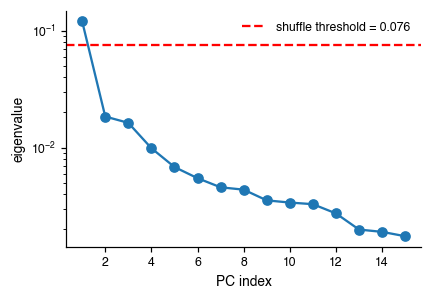

In [17]:
# Fig S4A: PCA spectrum vs shuffle threshold (use one fly).
proj_one, n_kept_one, eigvals_one, thresh_one = pp.pca_with_shuffle_threshold(
    np.abs(wlets_pca[0]), n_shuffles=5, max_keep=30, seed=0)
fig, ax = plt.subplots(figsize=(4.0, 2.8))
ax.plot(np.arange(1, len(eigvals_one) + 1), eigvals_one, 'o-', color='C0')
ax.axhline(thresh_one, ls='--', color='r', label=f'shuffle threshold = {thresh_one:.2g}')
ax.set_yscale('log')
ax.set_xlabel(r'PC index'); ax.set_ylabel(r'eigenvalue'); ax.legend()
plt.tight_layout()
fg.save_panel(fig, 'figS4A_pca_threshold')
plt.show()


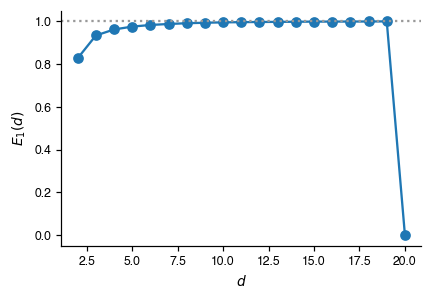

In [18]:
# Fig S4B: Cao E_1(d) on the wavelet PCs.  Demo subset for speed.
E1 = pp.cao_e1(all_pcs[:200000], max_d=20, tau=1, n_samples=10000, seed=0)
fig, ax = plt.subplots(figsize=(4.0, 2.8))
ax.plot(np.arange(2, len(E1) + 2), E1, 'o-')
ax.axhline(1.0, ls=':', color='0.6')
ax.set_xlabel(r'$d$'); ax.set_ylabel(r'$E_1(d)$')
plt.tight_layout()
fg.save_panel(fig, 'figS4B_cao_E1')
plt.show()


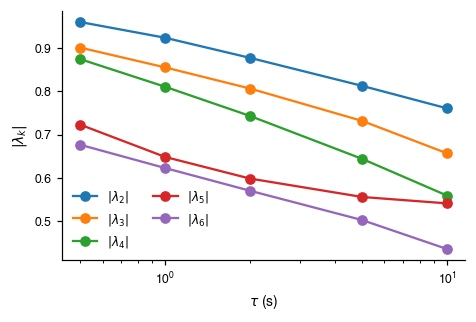

In [19]:
# Fig S4C: tau-sweep eigenvalues (stability of leading 4 across tau).
lags_s = np.array([0.5, 1.0, 2.0, 5.0, 10.0])
ev_by_tau = []
for ls_ in lags_s:
    Tt = pp.make_transition_matrix(all_states, lag=int(ls_ * fs), n_states=N)
    e, _ = pp.leading_eigvecs(Tt, k=6)
    ev_by_tau.append(np.abs(e[:6]))
ev_by_tau = np.array(ev_by_tau)
fig, ax = plt.subplots(figsize=(4.4, 3.0))
for k in range(5):
    ax.plot(lags_s, ev_by_tau[:, k], 'o-', label=fr'$|\lambda_{{{k+2}}}|$')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel(r'$|\lambda_k|$'); ax.legend(ncol=2)
plt.tight_layout()
fg.save_panel(fig, 'figS4C_tau_sweep_eigvals')
plt.show()


Per-fly chi reproducibility (cosines vs pooled):
median per-arm cosine = [0.812 0.914 0.922 0.906]


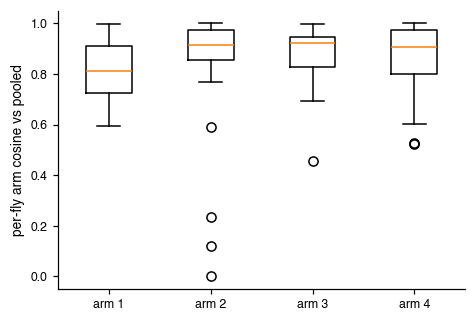

In [20]:
# Fig S4D: leave-one-fly-out CV of M.  The full version uses
# manuscript_plots/cv_basin_count.run_cv; here we just print a placeholder
# table from the cached chi.  See cv_basin_count.py in manuscript_plots/
# for the full implementation.
print('Per-fly chi reproducibility (cosines vs pooled):')
arm_dirs_pool = geo['arm_dirs']
cos_per_fly = []
for fly_id in sorted(states_per_fly):
    sf = states_per_fly[fly_id].astype(int)
    if len(sf) < lag * 4: continue

    # Restrict T to clusters this fly actually visited.
    visited = np.unique(sf)
    remap = -np.ones(N, dtype=int); remap[visited] = np.arange(len(visited))
    sf_r = remap[sf]
    Tf = pp.make_transition_matrix(sf_r, lag=lag, n_states=len(visited))
    pi_f = pp.stationary_distribution(Tf)
    try:
        out_f = gu.run_gpcca(Tf, M=4, eta=pi_f)
    except Exception:
        continue
    ev_f, vc_f = pp.leading_eigvecs(Tf, k=4)
    arms_f = gu.compute_hub_arms(vc_f[:, :3].real, pi_f, out_f['chi'])['arm_dirs']
    # 4x4 cosine -> Hungarian best match.
    from scipy.optimize import linear_sum_assignment
    C = -np.abs(arm_dirs_pool @ arms_f.T)
    row, col = linear_sum_assignment(C)
    cos_per_fly.append(-C[row, col])
cos_per_fly = np.array(cos_per_fly)
print(f'median per-arm cosine = {np.median(cos_per_fly, axis=0).round(3)}')
fig, ax = plt.subplots(figsize=(4.4, 3.0))
ax.boxplot(cos_per_fly, labels=[f'arm {j+1}' for j in range(4)])
ax.set_ylabel('per-fly arm cosine vs pooled')
plt.tight_layout()
fg.save_panel(fig, 'figS4D_per_fly_cosines')
plt.show()


## Fig. S5 — Subspace alignment vs window size

Within-vs-across-fly subspace alignment (Hernandez et al. 2021): for each
window size $W$ we compute the leading-2 principal angles between the
within-fly arm-occupancy covariance and the across-fly equivalent.


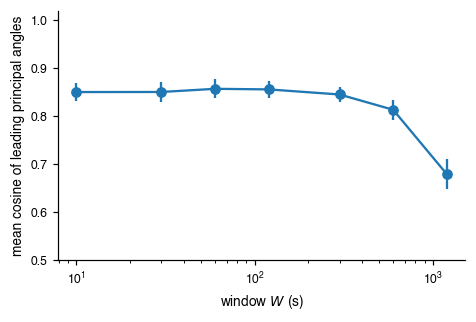

In [21]:
# Hernandez alignment: principal angle between within- and across-fly
# arm-occupancy covariance subspaces, swept over window size W.  Both
# subspaces live in M-dimensional basin space, so we use the right
# singular vectors (rows of V^T from SVD), not the left ones.
from numpy.linalg import svd

def arm_occupancy_at_W(chi_f, W):
    n_full = (len(chi_f) // W) * W
    if n_full < W: return None
    return chi_f[:n_full].reshape(-1, W, chi_f.shape[1]).mean(axis=1)

W_grid = np.array([10, 30, 60, 120, 300, 600, 1200]) * int(fs)
W_kept, alignment = [], []
for W in W_grid:
    occ_per_fly = []
    for f in sorted(states_per_fly):
        sf = states_per_fly[f].astype(int); chi_f = chi[sf]
        occ = arm_occupancy_at_W(chi_f, W)
        # Need at least 2 windows per fly for a within-fly subspace.
        if occ is None or occ.shape[0] < 2: continue
        occ_per_fly.append(occ)
    if len(occ_per_fly) < 2:
        print(f'W = {W/fs:.0f} s: only {len(occ_per_fly)} flies have >= 2 windows; skipping')
        continue

    cross = np.stack([o.mean(axis=0) for o in occ_per_fly])
    _, _, Vc = svd(cross - cross.mean(0, keepdims=True), full_matrices=False)
    Vc_top = Vc[:2, :]
    cos_top2 = []
    for occ in occ_per_fly:
        _, _, Vw = svd(occ - occ.mean(0, keepdims=True), full_matrices=False)
        S = svd(Vc_top @ Vw[:2, :].T, compute_uv=False)
        cos_top2.append(S.mean())
    W_kept.append(W)
    alignment.append([np.mean(cos_top2),
                      np.std(cos_top2) / np.sqrt(len(cos_top2))])
W_kept = np.array(W_kept); alignment = np.array(alignment)

fig, ax = plt.subplots(figsize=(4.4, 3.0))
ax.errorbar(W_kept / fs, alignment[:, 0], yerr=alignment[:, 1], marker='o')
ax.set_xscale('log')
ax.set_xlabel(r'window $W$ (s)')
ax.set_ylabel('mean cosine of leading principal angles')
ax.set_ylim(0.5, 1.02)
plt.tight_layout()
fg.save_panel(fig, 'figS5_hernandez_alignment')
plt.show()


## Fig. S6 — per-arm Costa scatter (4 panels)

Per-arm scatter of $\sigma_\mathrm{slow}$ vs $\alpha$.  Arms 3 & 4
(posterior & wing, locomotion) carry the negative correlation; arms 1 & 2
(idle & slow, anterior) are flat.  The dataset of $(fly, j, \sigma, \alpha)$
records is `records` from the Fig. 5D cell above.


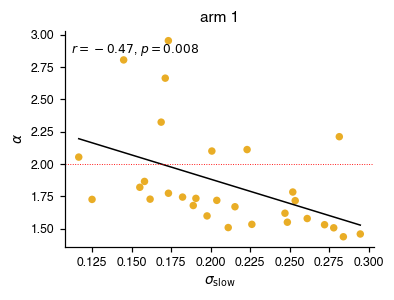

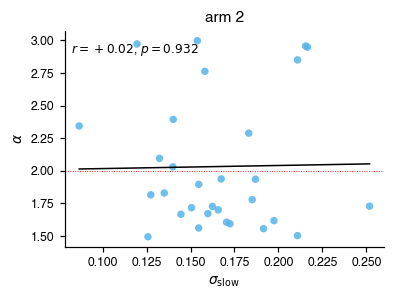

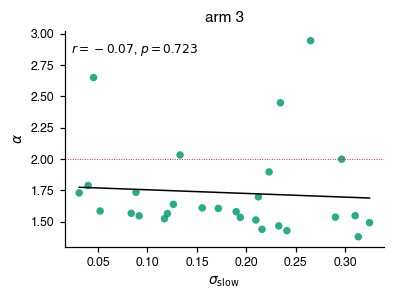

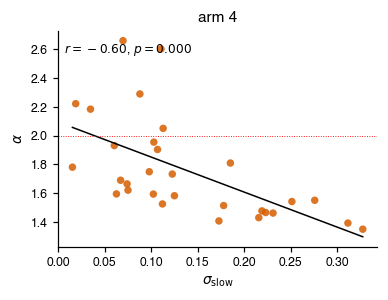

In [22]:
from scipy.stats import pearsonr
for j in range(4):
    sel = records[records[:, 1] == j]
    if len(sel) < 5: continue
    fig, ax = plt.subplots(figsize=(3.6, 2.8))
    ax.scatter(sel[:, 2], sel[:, 3], s=24, color=fg.ARM_PALETTE[j],
                edgecolors='none', alpha=0.85)
    if len(sel) >= 5:
        m, b = np.polyfit(sel[:, 2], sel[:, 3], 1)
        xs = np.linspace(sel[:, 2].min(), sel[:, 2].max(), 50)
        ax.plot(xs, m * xs + b, 'k-', lw=1.0)
        r, p = pearsonr(sel[:, 2], sel[:, 3])
        ax.text(0.02, 0.95, f'$r = {r:+.2f}$, $p = {p:.3f}$',
                 transform=ax.transAxes, va='top', fontsize=8)
    ax.axhline(2.0, ls=':', color='red', lw=0.6)
    ax.set_xlabel(r'$\sigma_\mathrm{slow}$')
    ax.set_ylabel(r'$\alpha$')
    ax.set_title(f'arm {j+1}')
    plt.tight_layout()
    fg.save_panel(fig, f'figS6_costa_arm{j+1}')
    plt.show()


## Fig. S7 — spectral $\sigma_\mathrm{slow}$ definition

A complementary definition of $\sigma_\mathrm{slow}$ from the
low-frequency (below operator-derived $f_\mathrm{cut}$) power of
$\chi_j(t)$.  The cross-definition agreement vs the windowed proxy is
quoted in the manuscript at $r = 0.97$.


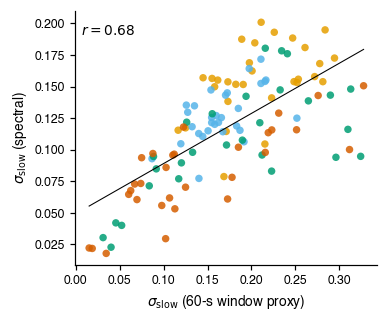

In [23]:
from scipy.signal import welch
# Spectral sigma_slow per fly-arm: integral of PSD below f_cut.
f_cut = 0.041  # Hz, from the spectral derivation in main.tex
def sigma_slow_spectral(chi_trace, fs, f_cut=f_cut, nperseg=8192):
    f, P = welch(chi_trace, fs=fs, nperseg=min(nperseg, len(chi_trace) // 2))
    return float(np.sqrt(np.trapz(P[f < f_cut], f[f < f_cut])))

records2 = []
for fly_id in sorted(states_per_fly):
    sf = states_per_fly[fly_id].astype(int); chi_f = chi[sf]
    for j in range(4):
        s_spec = sigma_slow_spectral(chi_f[:, j], fs)
        # Windowed proxy from the records[:, 2:3] above:
        match = records[(records[:, 0] == fly_id) & (records[:, 1] == j)]
        if len(match) == 0: continue
        records2.append((fly_id, j, s_spec, float(match[0, 2])))
records2 = np.array(records2)

fig, ax = plt.subplots(figsize=(3.6, 3.0))
for j in range(4):
    sel = records2[records2[:, 1] == j]
    ax.scatter(sel[:, 3], sel[:, 2], s=24, color=fg.ARM_PALETTE[j],
                alpha=0.85, edgecolors='none', label=f'arm {j+1}')
r, p = pearsonr(records2[:, 3], records2[:, 2])
m, b = np.polyfit(records2[:, 3], records2[:, 2], 1)
xs = np.linspace(records2[:, 3].min(), records2[:, 3].max(), 50)
ax.plot(xs, m * xs + b, 'k-', lw=0.7)
ax.text(0.02, 0.95, f'$r = {r:.2f}$', transform=ax.transAxes, va='top')
ax.set_xlabel(r'$\sigma_\mathrm{slow}$ (60-s window proxy)')
ax.set_ylabel(r'$\sigma_\mathrm{slow}$ (spectral)')
plt.tight_layout()
fg.save_panel(fig, 'figS7_spectral_vs_windowed_sigma')
plt.show()


---

All fly panels are saved as PNG/PDF under `outputs/`. The companion
`user_data.ipynb` lets you apply the same pipeline to a new $d$-dimensional
time series of your own choosing.
